# Libraries

In [1]:
import pandas as pd
import numpy as np
import pycld2 as cld2
from tqdm import tqdm

In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
import spacy
from spacy.tokens import Doc

nltk.download('punkt')
nltk.download("stopwords")
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Airbnb

## Dataset

In [4]:
# Bergamo
be_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Bergamo\reviews.csv")
be_rev['Location']= 'Bergamo'

# Bologna
bo_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Bologna\reviews.csv")
bo_rev['Location']= 'Bologna'

# Florence
flo_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Florence\reviews.csv")
flo_rev['Location']= 'Florence'

# Milan
mi_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Milan\reviews.csv")
mi_rev['Location']= 'Milan'

# Naples
nap_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Naples\reviews.csv")
nap_rev['Location']= 'Naples'

# Puglia
pu_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Puglia\reviews.csv")
pu_rev['Location']= 'Puglia'

# Rome
ro_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Rome\reviews.csv")
ro_rev['Location']= 'Rome'

# Sicily
si_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Sicily\reviews.csv")
si_rev['Location']= 'Sicily'

# Trentino
tre_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Trentino\reviews.csv")
tre_rev['Location']= 'Trentino'

# Venice
ve_rev = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\Airbnb Data\Venice\reviews.csv")
ve_rev['Location']= 'Trentino'

In [5]:
airbnb_reviews = pd.concat([be_rev, bo_rev, flo_rev, mi_rev, nap_rev, pu_rev, ro_rev, si_rev, tre_rev, ve_rev],
                           ignore_index=True)

airbnb_reviews

,listing_id,id,date,reviewer_id,reviewer_name,comments,Location
0,15526,314442,2011-06-14,324113,Modestas,We went for weekends experience to Italy to st...,Bergamo
1,15526,408859,2011-07-31,788193,Jon,"The view from the terrace is amazing, even bet...",Bergamo
2,15526,2369937,2012-09-22,3148551,Oriane,Maison splendide. Accueil très agréable. Ernes...,Bergamo
3,15526,6324796,2013-08-08,397704,Martin,Abbiamo passato cinque notti al Palazzo e ci s...,Bergamo
4,15526,14113480,2014-06-12,4789610,Lissy,It was so fantastic to stay in Palazzo. The wa...,Bergamo
...,...,...,...,...,...,...,...
7141839,1407885990156151182,1430422775739068801,2025-05-27,562601467,Mireya,El hospedaje tiene buena ubicación muy cerca d...,Trentino
7141840,1407885990156151182,1434668326008614280,2025-06-02,425145617,Giuseppe,Very nice location on the island of Venice. Ea...,Trentino
7141841,1407885990156151182,1436278168608173865,2025-06-04,494316262,Gavin,DO NOT BOOK DAY OF The host utilized automated...,Trentino
7141842,1407885990156151182,1436934662119415406,2025-06-05,337943657,Shayan,"everything is good,",Trentino


In [6]:
airbnb_reviews['n_words'] = (
    airbnb_reviews['comments']
    .fillna('')
    .astype(str)
    .str.count(r'\S+')
)

In [7]:
airbnb_reviews.describe()

,listing_id,id,reviewer_id,n_words
count,7.141844e+06,7.141844e+06,7.141844e+06,7.141844e+06
mean,2.226612e+17,6.893708e+17,1.792902e+08,4.479118e+01
std,3.989253e+17,5.067129e+17,1.725140e+08,4.173175e+01
min,2.737000e+03,8.283000e+03,2.000000e+00,0.000000e+00
25%,1.156477e+07,5.507629e+08,3.756109e+07,1.600000e+01
50%,2.771225e+07,8.237149e+17,1.167037e+08,3.400000e+01
75%,5.441771e+17,1.153562e+18,2.765417e+08,6.000000e+01
max,1.441812e+18,1.447096e+18,7.018675e+08,1.000000e+03


In [8]:
float('6.000000e+01')

60.0

In [9]:
# I will exctract only until the upper quartile (75%)
airbnb_reviews = airbnb_reviews[airbnb_reviews['n_words'] <= 60]

In [10]:
len(airbnb_reviews)

5383460

In [11]:
airbnb_reviews_copy = airbnb_reviews

In [12]:
airbnb_reviews_copy["comments"] = airbnb_reviews_copy["comments"].fillna("").astype(str)
#airbnb_reviews_copy["lang"] = airbnb_reviews_copy["comments"].apply(lambda s: langid.classify(s)[0] if s.strip() else "unk")

C:\Users\franc\AppData\Local\Temp\ipykernel_8748\1976117428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airbnb_reviews_copy["comments"] = airbnb_reviews_copy["comments"].fillna("").astype(str)


In [13]:
langs = []
for s in tqdm(airbnb_reviews_copy["comments"].tolist(), desc="Detectando idioma"):
    s = s.strip()
    if not s:
        langs.append("unk")
        continue
    try:
        isReliable, textBytesFound, details = cld2.detect(s)
        lang = details[0][1]  # ej. 'ENGLISH'
        code = details[0][0]  # ej. 'en'
        langs.append(code.lower())
    except Exception:
        langs.append("unk")

airbnb_reviews_copy["lang"] = langs

Detectando idioma: 100%|██████████| 5383460/5383460 [01:06<00:00, 81384.37it/s] 
C:\Users\franc\AppData\Local\Temp\ipykernel_8748\3539210939.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airbnb_reviews_copy["lang"] = langs


In [14]:
airbnb_reviews_copy.head(10)

,listing_id,id,date,reviewer_id,reviewer_name,comments,Location,n_words,lang
0,15526,314442,2011-06-14,324113,Modestas,We went for weekends experience to Italy to st...,Bergamo,60,english
1,15526,408859,2011-07-31,788193,Jon,"The view from the terrace is amazing, even bet...",Bergamo,31,english
2,15526,2369937,2012-09-22,3148551,Oriane,Maison splendide. Accueil très agréable. Ernes...,Bergamo,20,french
3,15526,6324796,2013-08-08,397704,Martin,Abbiamo passato cinque notti al Palazzo e ci s...,Bergamo,56,italian
4,15526,14113480,2014-06-12,4789610,Lissy,It was so fantastic to stay in Palazzo. The wa...,Bergamo,57,english
5,15526,14572624,2014-06-22,12509472,Marco,A beautiful place in a gorgeous landscape! Ern...,Bergamo,50,english
6,15526,18781417,2014-09-01,5840939,Lucia,It was unforgettable. Every morning we enjoyed...,Bergamo,56,english
10,15526,58909627,2016-01-05,49402478,Sofia,Spaziosa e accogliente residenza che abbiamo a...,Bergamo,41,italian
13,15526,94715749,2016-08-16,39898099,Diego,Abbiamo trascorso alcuni giorni all'interno de...,Bergamo,54,italian
16,15526,105916575,2016-10-03,10149370,Monika,"Im Vorfeld hat sich Maurizio erkundigt, wann w...",Bergamo,45,german


In [15]:
airbnb_reviews_copy['lang'].value_counts()

lang
english    2800779
italian     866559
french      554692
spanish     328370
german      246455
            ...   
tagalog          1
nyanja           1
oromo            1
quechua          1
khmer            1
Name: count, Length: 113, dtype: int64

In [16]:
# For optimization and also focusing in international tourists
airbnb_reviews_copy = airbnb_reviews_copy[airbnb_reviews_copy['lang'] == 'english'].copy()

In [17]:
airbnb_reviews_copy

,listing_id,id,date,reviewer_id,reviewer_name,comments,Location,n_words,lang
0,15526,314442,2011-06-14,324113,Modestas,We went for weekends experience to Italy to st...,Bergamo,60,english
1,15526,408859,2011-07-31,788193,Jon,"The view from the terrace is amazing, even bet...",Bergamo,31,english
4,15526,14113480,2014-06-12,4789610,Lissy,It was so fantastic to stay in Palazzo. The wa...,Bergamo,57,english
5,15526,14572624,2014-06-22,12509472,Marco,A beautiful place in a gorgeous landscape! Ern...,Bergamo,50,english
6,15526,18781417,2014-09-01,5840939,Lucia,It was unforgettable. Every morning we enjoyed...,Bergamo,56,english
...,...,...,...,...,...,...,...,...,...
7141835,1407854053189821432,1434674614243794017,2025-06-02,404529248,Ambrish,"Guest services were great, well accommodating....",Trentino,29,english
7141836,1407854053189821432,1436211735511288801,2025-06-04,582485370,Broderick,"Great stay, easy, clean and relatively afforda...",Trentino,12,english
7141840,1407885990156151182,1434668326008614280,2025-06-02,425145617,Giuseppe,Very nice location on the island of Venice. Ea...,Trentino,23,english
7141842,1407885990156151182,1436934662119415406,2025-06-05,337943657,Shayan,"everything is good,",Trentino,3,english


## Text Mining & Analysis

### Preparation

In [18]:
# As this is not the main objective of the thesis, and having too many rows (millions) it may last for too much,
# it was decided to use a 15% of the dataset
airbnb_reviews_sample = airbnb_reviews_copy.sample(frac=0.15, random_state=42)

In [19]:
airbnb_reviews_sample["comments"] = airbnb_reviews_sample["comments"].fillna("").astype(str)

### Tokenization & Normalization

In [20]:
airbnb_reviews_sample["tokens"] = airbnb_reviews_sample["comments"].apply(lambda text: [tok.lower() for tok in word_tokenize(text)] if text.strip() else [])

In [21]:
airbnb_reviews_sample.head(2)

,listing_id,id,date,reviewer_id,reviewer_name,comments,Location,n_words,lang,tokens
4649682,53915146,985356817571078082,2023-09-21,519982023,Hussain,Vito’s hospitality was unmatched! Superb apart...,Rome,18,english,"[vito, ’, s, hospitality, was, unmatched, !, s..."
3888899,14043928,677298680378945050,2022-07-23,404440874,Anneke,Lovely apartment close to all sights of Rome. ...,Rome,15,english,"[lovely, apartment, close, to, all, sights, of..."


### Removing Stopwords & Punctuation

In [22]:
stop_words = set(stopwords.words("english"))
punctuation = set(string.punctuation)

In [23]:
def stopwords_cleaner(tokens):
    return [tok for tok in tokens if tok not in stop_words and tok not in punctuation]

In [24]:
airbnb_reviews_sample["clean_tokens"] = airbnb_reviews_sample["tokens"].apply(stopwords_cleaner)

In [25]:
airbnb_reviews_sample.head(2)

,listing_id,id,date,reviewer_id,reviewer_name,comments,Location,n_words,lang,tokens,clean_tokens
4649682,53915146,985356817571078082,2023-09-21,519982023,Hussain,Vito’s hospitality was unmatched! Superb apart...,Rome,18,english,"[vito, ’, s, hospitality, was, unmatched, !, s...","[vito, ’, hospitality, unmatched, superb, apar..."
3888899,14043928,677298680378945050,2022-07-23,404440874,Anneke,Lovely apartment close to all sights of Rome. ...,Rome,15,english,"[lovely, apartment, close, to, all, sights, of...","[lovely, apartment, close, sights, rome, airco..."


### Lemmtization

In [26]:
lemma_token_list  = []

texts = [" ".join(tokens) for tokens in airbnb_reviews_sample["clean_tokens"]]

for doc in nlp.pipe(texts, batch_size=2000, n_process=4):
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    lemma_token_list.append(lemmas)

In [27]:
airbnb_reviews_sample["text_lemma"] = lemma_token_list

In [28]:
airbnb_reviews_sample.head(3)

,listing_id,id,date,reviewer_id,reviewer_name,comments,Location,n_words,lang,tokens,clean_tokens,text_lemma
4649682,53915146,985356817571078082,2023-09-21,519982023,Hussain,Vito’s hospitality was unmatched! Superb apart...,Rome,18,english,"[vito, ’, s, hospitality, was, unmatched, !, s...","[vito, ’, hospitality, unmatched, superb, apar...","[vito, hospitality, unmatched, superb, apartme..."
3888899,14043928,677298680378945050,2022-07-23,404440874,Anneke,Lovely apartment close to all sights of Rome. ...,Rome,15,english,"[lovely, apartment, close, to, all, sights, of...","[lovely, apartment, close, sights, rome, airco...","[lovely, apartment, close, sight, rome, aircon..."
4730897,633903300963263556,709956720105040181,2022-09-06,3588467,Andrew,Francesco’s apartment is very modern and is co...,Rome,36,english,"[francesco, ’, s, apartment, is, very, modern,...","[francesco, ’, apartment, modern, conveniently...","[francesco, apartment, modern, conveniently, l..."


### TF-IDF & Word Clouding

In [29]:
airbnb_reviews_sample["text_lemma"] = airbnb_reviews_sample["text_lemma"].apply(lambda x: x if isinstance(x, list) else [])

In [30]:
doc = airbnb_reviews_sample["text_lemma"].apply(" ".join).tolist()

In [31]:
# Only 1 token
vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8,
    max_features=100_000,
    dtype=np.float32
)

X = vectorizer.fit_transform(doc)
terms = vectorizer.get_feature_names_out()

In [32]:
scores = np.asarray(X.sum(axis=0)).ravel()
tfidf = dict(zip(terms, scores))

In [33]:
wc = WordCloud(width=1400, height=700, background_color="white")

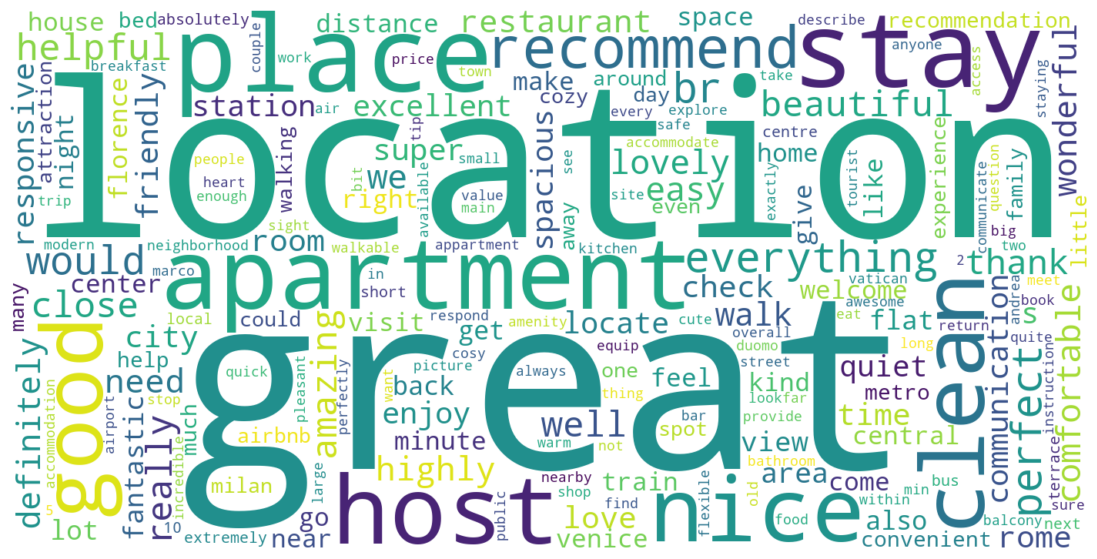

In [34]:
wc_airbnb = wc.generate_from_frequencies(tfidf)

plt.figure(figsize=(14,7))
plt.imshow(wc_airbnb, interpolation="bilinear")
plt.axis("off")
plt.show()

In [35]:
top_idx = np.argsort(scores)[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms[top_idx],
    "tfidf_sum": scores[top_idx]
})
display(top_terms)

,term,tfidf_sum
0,great,28329.458984
1,location,21723.058594
2,place,21542.238281
3,stay,21112.201172
4,apartment,18751.130859
5,host,16966.738281
6,nice,14931.644531
7,clean,14337.011719
8,good,13278.189453
9,recommend,12959.979492


In [36]:
# 3 tokens
vectorizer_ngrams = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(3,3),   # (2,3) si quieres bi+tri
    min_df=5, max_df=0.8, max_features=300_000, dtype=np.float32
)

In [37]:
X2 = vectorizer_ngrams.fit_transform(doc)
terms3 = vectorizer_ngrams.get_feature_names_out()
scores3 = np.asarray(X2.sum(axis=0)).ravel()
tfidf_tri = dict(zip(terms3, scores3))

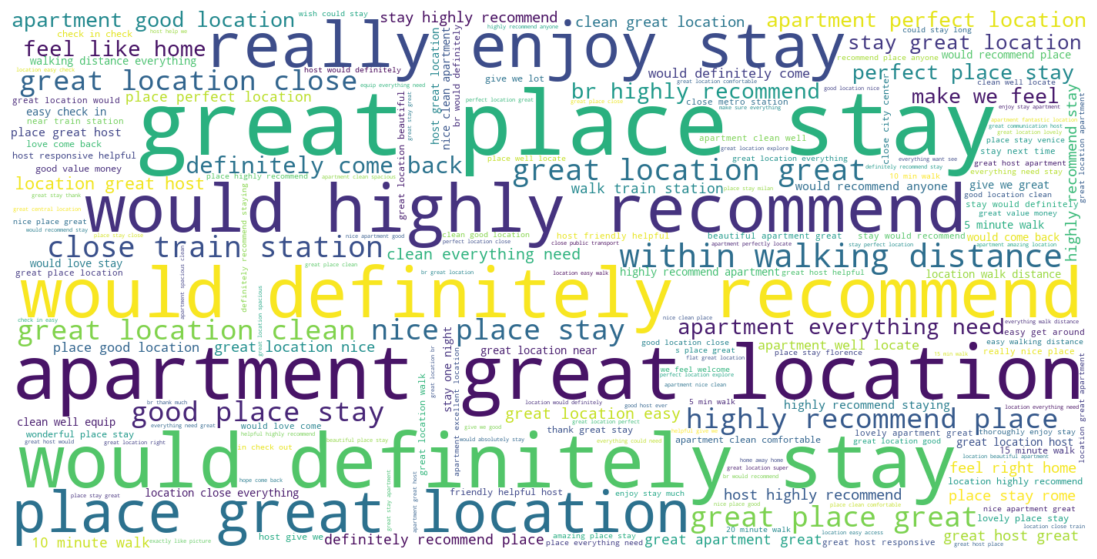

In [38]:
wc_tri = WordCloud(width=1400, height=700, background_color="white")
wc_tri_airbnb = wc_tri.generate_from_frequencies(tfidf_tri)
plt.figure(figsize=(14,7))
plt.imshow(wc_tri_airbnb, interpolation="bilinear")
plt.axis("off")
plt.show()

In [39]:
top_idx = np.argsort(scores3)[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms3[top_idx],
    "tfidf_sum": scores3[top_idx]
})
display(top_terms)

,term,tfidf_sum
0,great place stay,2129.647705
1,apartment great location,1440.057251
2,would definitely stay,1436.977417
3,would definitely recommend,1376.131104
4,would highly recommend,1297.693604
5,really enjoy stay,1151.424683
6,place great location,1150.737183
7,within walking distance,915.602173
8,great location great,748.339294
9,close train station,733.274841


# Booking

## Dataset

In [40]:
booking_reviews = pd.read_csv(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Analysis\booking_reviews.csv")

In [41]:
df_booking = booking_reviews[['reviewed_by', 'hotel_name', 'rating', 'review_text']]

While working on the dataset, there were several "There are no comments available for this review".

This i why it will be removed, as one of the most common words was "available".

In [42]:
df_booking = booking_reviews.loc[
    booking_reviews["review_text"].str.strip().ne(
        "There are no comments available for this review"
    )
].copy()

In [43]:
len(df_booking)

18988

In [44]:
df_booking.head(2)

,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b..."


## Text Mining & Analysis

### Preparation

In [45]:
df_booking["review_text"] = df_booking["review_text"].fillna("").astype(str)

### Tokenization & Normalization

In [46]:
df_booking["tokens"] = df_booking["review_text"].apply(lambda text: [tok.lower() for tok in word_tokenize(text)] if text.strip() else [])

In [47]:
df_booking.head(2)

,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta,tokens
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b...","[everything, was, perfect, !, quite, ,, cozy, ..."
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b...","[very, friendly, host, and, perfect, breakfast..."


### Removing Stopwords & Punctuation

In [48]:
stop_words = set(stopwords.words("english"))
punctuation = set(string.punctuation)

In [49]:
df_booking["clean_tokens"] = df_booking["tokens"].apply(stopwords_cleaner)

In [50]:
df_booking.head(3)

,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta,tokens,clean_tokens
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b...","[everything, was, perfect, !, quite, ,, cozy, ...","[everything, perfect, quite, cozy, place, relax]"
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b...","[very, friendly, host, and, perfect, breakfast...","[friendly, host, perfect, breakfast]"
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b...","[it, was, just, what, we, wanted, for, a, week...","[wanted, week, beach, winter, location, fab, a..."


### Lemmatization

In [51]:
def lemma(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if not token.is_punct and not token.is_space]

In [52]:
df_booking["lemmas"] = df_booking["clean_tokens"].apply(lemma)

In [53]:
df_booking.head(3)

,index,review_title,reviewed_at,reviewed_by,images,crawled_at,url,hotel_name,hotel_url,avg_rating,nationality,rating,review_text,raw_review_text,tags,meta,tokens,clean_tokens,lemmas
0,0,Exceptional,11 July 2021,Kyrylo,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...","<p class=""review_pos ""><svg aria-label=""Positi...",Business trip~Solo traveller~Junior Suite~Stay...,"{'language': 'en-gb', 'source': 'https://www.b...","[everything, was, perfect, !, quite, ,, cozy, ...","[everything, perfect, quite, cozy, place, relax]","[everything, perfect, quite, cozy, place, relax]"
1,1,I highly recommend this b&b! We enjoyed it a lot!,24 November 2019,Dimitri,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/villa...,Villa Pura Vida,https://www.booking.com/hotel/be/villa-pura-vi...,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,"<p class=""review_pos ""><svg aria-label=""Positi...",Leisure trip~Couple~Deluxe Suite~Stayed 1 nigh...,"{'language': 'en-gb', 'source': 'https://www.b...","[very, friendly, host, and, perfect, breakfast...","[friendly, host, perfect, breakfast]","[friendly, host, perfect, breakfast]"
2,2,Exceptional,3 January 2020,Virginia,NaN,"07/20/2021, 01:09:27",https://www.booking.com/reviews/be/hotel/hydro...,Hydro Palace Apartment,https://www.booking.com/hotel/be/hydro-palace....,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,"<p class=""review_neg ""><svg aria-label=""Negati...",Leisure trip~Couple~Apartment with Sea View~St...,"{'language': 'en-gb', 'source': 'https://www.b...","[it, was, just, what, we, wanted, for, a, week...","[wanted, week, beach, winter, location, fab, a...","[want, week, beach, winter, location, fab, apa..."


### TF-IDF & Word Clouding

In [54]:
df_booking["lemmas"] = df_booking["lemmas"].apply(lambda x: x if isinstance(x, list) else [])

#### Positive Booking Reviews

In [55]:
df_booking_positive = df_booking[df_booking['rating'] >= 7]

In [56]:
remove_set = {"review", "comment"}

df_booking_positive["lemmas"] = df_booking_positive["lemmas"].apply(
    lambda toks: [t for t in toks if t not in remove_set]
)

C:\Users\franc\AppData\Local\Temp\ipykernel_8748\4256908043.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_booking_positive["lemmas"] = df_booking_positive["lemmas"].apply(


In [57]:
docs_positive = df_booking_positive["lemmas"].apply(" ".join).tolist()

In [58]:
# Only 1 token
vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8,
    max_features=100_000,
    dtype=np.float32
)

X = vectorizer.fit_transform(docs_positive)
terms_positive = vectorizer.get_feature_names_out()

In [59]:
scores_positive = np.asarray(X.sum(axis=0)).ravel()
positive_tfidf = dict(zip(terms_positive, scores_positive))

In [60]:
wc = WordCloud(width=1400, height=700, background_color="white")

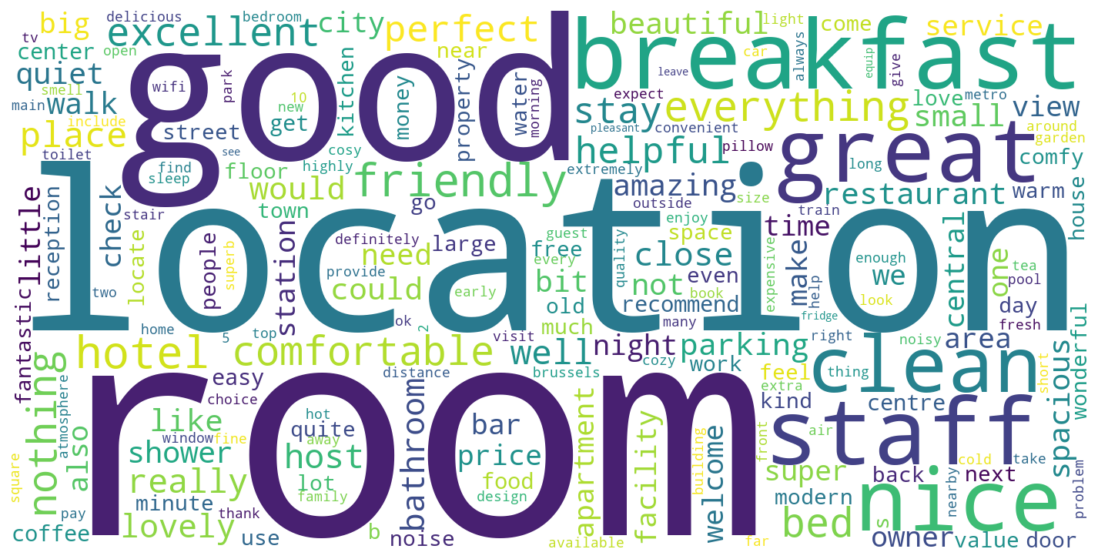

In [61]:
wc_positive = wc.generate_from_frequencies(positive_tfidf)

plt.figure(figsize=(14,7))
plt.imshow(wc_positive, interpolation="bilinear")
plt.axis("off")
plt.show()

In [62]:
top_idx = np.argsort(scores_positive)[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms_positive[top_idx],
    "tfidf_sum": scores_positive[top_idx]
})
display(top_terms)

,term,tfidf_sum
0,room,885.165710
1,location,845.207275
2,good,731.863708
3,breakfast,713.956909
4,staff,658.105530
5,great,625.351135
6,nice,581.880920
7,clean,561.807068
8,friendly,527.459656
9,hotel,514.961304


In [63]:
# 3 tokens
vectorizer_ngrams = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(3,3),   # (2,3) si quieres bi+tri
    min_df=5, max_df=0.8, max_features=300_000, dtype=np.float32
)

In [64]:
X2 = vectorizer_ngrams.fit_transform(docs_positive)
terms3_positive = vectorizer_ngrams.get_feature_names_out()
scores3_positive = np.asarray(X2.sum(axis=0)).ravel()
tfidf_tri = dict(zip(terms3_positive, scores3_positive))

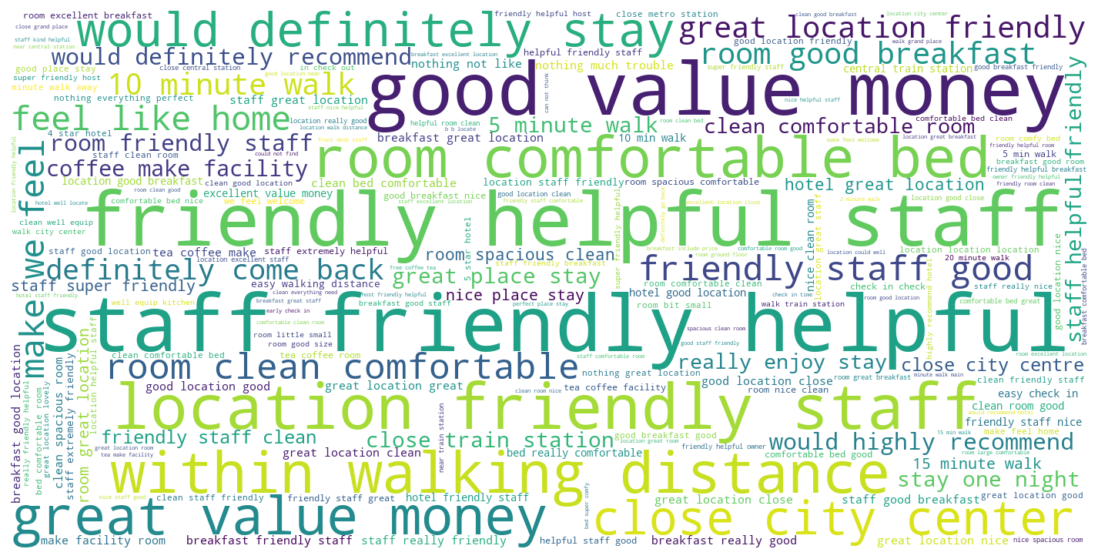

In [65]:
wc_tri = WordCloud(width=1400, height=700, background_color="white")
wc_tri_positive = wc_tri.generate_from_frequencies(tfidf_tri)
plt.figure(figsize=(14,7))
plt.imshow(wc_tri_positive, interpolation="bilinear")
plt.axis("off")
plt.show()

In [66]:
top_idx = np.argsort(scores3_positive)[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms3_positive[top_idx],
    "tfidf_sum": scores3_positive[top_idx]
})
display(top_terms)

,term,tfidf_sum
0,staff friendly helpful,87.996552
1,friendly helpful staff,78.479317
2,good value money,77.460411
3,location friendly staff,53.965679
4,within walking distance,44.213612
5,room comfortable bed,43.443668
6,great value money,41.194393
7,would definitely stay,38.515179
8,close city center,37.898727
9,room clean comfortable,37.174404


In [67]:
df_booking_positive.to_csv('df_booking_positive.csv')

#### Negative Booking Reviews

In [68]:
df_booking_negative = df_booking[df_booking['rating'] < 7]

In [69]:
remove_set = {"review", "comment"}

df_booking_negative["lemmas"] = df_booking_negative["lemmas"].apply(
    lambda toks: [t for t in toks if t not in remove_set]
)

C:\Users\franc\AppData\Local\Temp\ipykernel_8748\3636045365.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_booking_negative["lemmas"] = df_booking_negative["lemmas"].apply(


In [70]:
docs_negative = df_booking_negative["lemmas"].apply(" ".join).tolist()

In [71]:
# Only 1 token
vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8,
    max_features=100_000,
    dtype=np.float32
)

X = vectorizer.fit_transform(docs_negative)
terms_negative = vectorizer.get_feature_names_out()

In [72]:
scores_negative = np.asarray(X.sum(axis=0)).ravel()
negative_tfidf = dict(zip(terms_negative, scores_negative))

In [73]:
wc = WordCloud(width=1400, height=700, background_color="white")

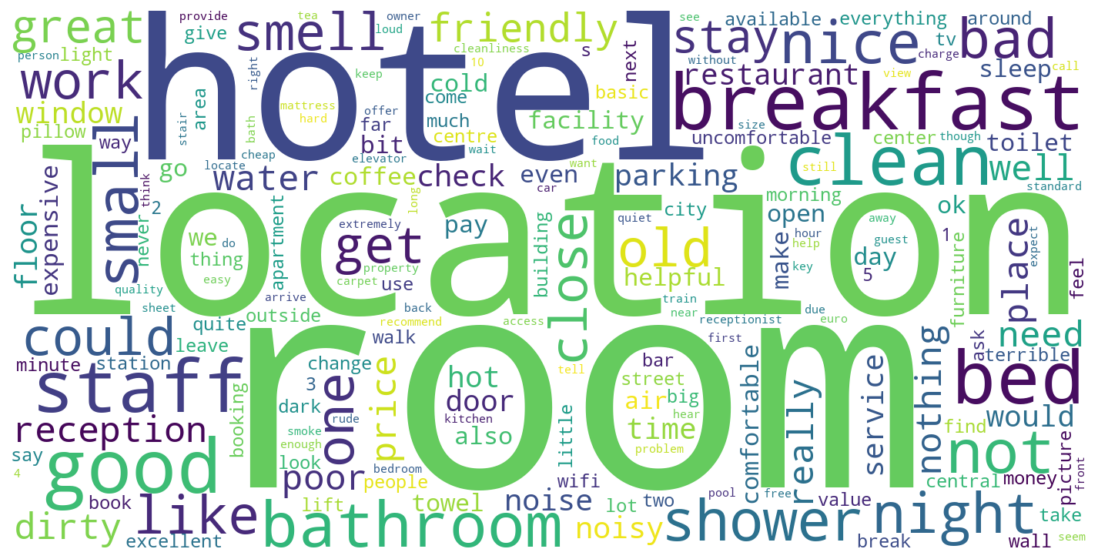

In [74]:
wc_negative = wc.generate_from_frequencies(negative_tfidf)

plt.figure(figsize=(14,7))
plt.imshow(wc_negative, interpolation="bilinear")
plt.axis("off")
plt.show()

In [75]:
top_idx = np.argsort(scores_negative)[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms_negative[top_idx],
    "tfidf_sum": scores_negative[top_idx]
})
display(top_terms)

,term,tfidf_sum
0,room,165.004501
1,location,113.209091
2,hotel,89.735794
3,breakfast,85.568939
4,good,79.810104
5,bed,76.736656
6,staff,75.363091
7,clean,71.173103
8,bathroom,57.191978
9,not,54.347340


In [76]:
# 3 tokens
vectorizer_ngrams = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(3,3),   # (2,3) si quieres bi+tri
    min_df=5, max_df=0.8, max_features=300_000, dtype=np.float32
)

In [77]:
X2 = vectorizer_ngrams.fit_transform(docs_negative)
terms3_negative = vectorizer_ngrams.get_feature_names_out()
scores3_negative = np.asarray(X2.sum(axis=0)).ravel()
tfidf_tri = dict(zip(terms3_negative, scores3_negative))

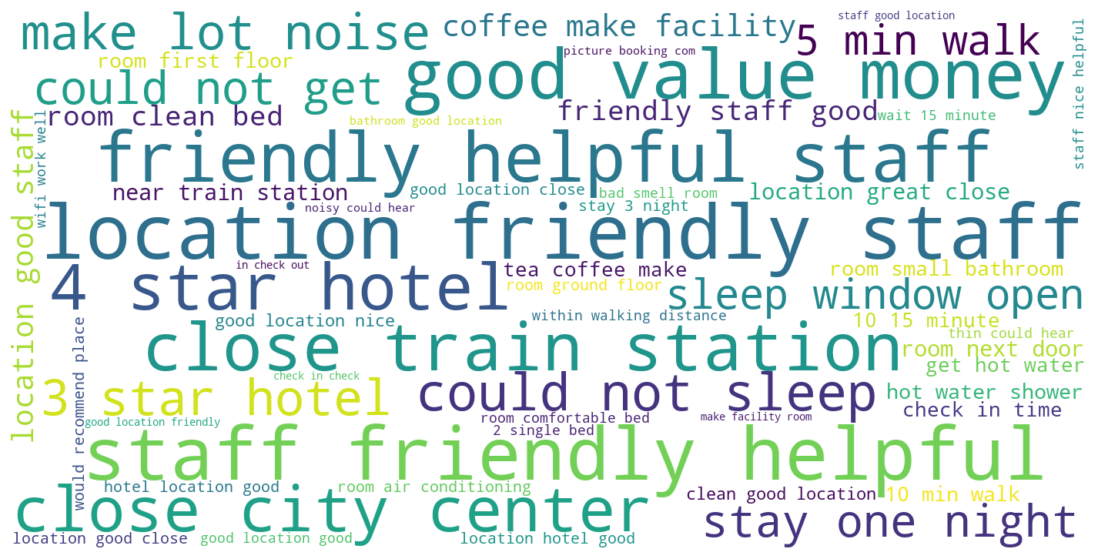

In [78]:
wc_tri = WordCloud(width=1400, height=700, background_color="white")
wc_tri_positive = wc_tri.generate_from_frequencies(tfidf_tri)
plt.figure(figsize=(14,7))
plt.imshow(wc_tri_positive, interpolation="bilinear")
plt.axis("off")
plt.show()

In [79]:
top_idx = np.argsort(scores3_negative)[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms3_negative[top_idx],
    "tfidf_sum": scores3_negative[top_idx]
})
display(top_terms)

,term,tfidf_sum
0,location friendly staff,12.968742
1,staff friendly helpful,12.378328
2,good value money,11.094788
3,friendly helpful staff,10.843116
4,close train station,10.064183
5,4 star hotel,9.386170
6,close city center,9.000000
7,could not sleep,9.000000
8,3 star hotel,8.492825
9,make lot noise,8.375647


In [80]:
df_booking_negative.to_csv('df_booking_negative.csv')